## RNN analizi

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical

# CSV yükle
df = pd.read_csv("indian_realestate_dataset_1000.csv")

# İlk 5 satır
print(df.head())

# Eksik veri temizleme
df = df.dropna()

# -------------------------
# TARGET OLUŞTURMA
# -------------------------
# price kolonunu sınıfa çeviriyoruz
# median üstü = pahalı (1)
# median altı = ucuz (0)

median_price = df["price_inr"].median()

df["target"] = (
    df["price_inr"] > median_price
).astype(int)

# -------------------------
# FEATURE / LABEL AYIRMA
# -------------------------
X = df.drop(["price_inr", "target"], axis=1)
y = df["target"]

# -------------------------
# KATEGORİK VERİLERİ ENCODE
# -------------------------
for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# -------------------------
# SCALE
# -------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -------------------------
# TRAIN TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# RNN İÇİN RESHAPE
# -------------------------
# RNN input:
# (samples, timesteps, features)

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# -------------------------
# MODEL
# -------------------------
model = Sequential()

model.add(SimpleRNN(
    32,
    activation='relu',
    input_shape=(1, X_train.shape[2])
))

model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# -------------------------
# COMPILE
# -------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# TRAIN
# -------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

# -------------------------
# PREDICT
# -------------------------
y_pred = model.predict(X_test)

# 0-1 dönüşümü
y_pred = (y_pred > 0.5).astype(int)

# -------------------------
# RAPOR
# -------------------------
print(classification_report(y_test, y_pred))

  property_id       city     district      property_type  built_up_area_sqft  \
0   PROP00001    Chennai   Anna Nagar          Apartment                1526   
1   PROP00002     Mumbai       Bandra             Studio                 424   
2   PROP00003    Chennai   Anna Nagar          Apartment                1333   
3   PROP00004       Pune  Viman Nagar  Independent House                4121   
4   PROP00005  Bangalore  Indiranagar              Villa                4020   

   price_inr  price_per_sqft_inr  bedrooms  bathrooms  age_years  ...  \
0   10000000                6553         2          1          4  ...   
1   50000000              117924         1          1          6  ...   
2   10000000                7501         3          1         27  ...   
3   15000000                3639         3          2         26  ...   
4   30000000                7462         5          3         28  ...   

  annual_rental_yield_pct price_category  estimated_roi_5yr_pct  listing_date  \

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5625 - loss: 0.6934 - val_accuracy: 0.7500 - val_loss: 0.5389
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8641 - loss: 0.4685 - val_accuracy: 0.9563 - val_loss: 0.3739
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9641 - loss: 0.3053 - val_accuracy: 0.9812 - val_loss: 0.2247
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9766 - loss: 0.1801 - val_accuracy: 0.9937 - val_loss: 0.1321
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9875 - loss: 0.1070 - val_accuracy: 0.9937 - val_loss: 0.0850
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9875 - loss: 0.0695 - val_accuracy: 0.9937 - val_loss: 0.0603
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9906 - loss: 0.0499 - val_accuracy: 0.9937 - val_loss: 0.0487
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9937 - loss: 0.0383 - val_accuracy: 0.9937 - val_loss

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    LSTM,
    GRU,
    Dropout
)

In [5]:
df = pd.read_csv("indian_realestate_dataset_1000.csv")

print(df.head())
print(df.columns)

df = df.dropna()

  property_id       city     district      property_type  built_up_area_sqft  \
0   PROP00001    Chennai   Anna Nagar          Apartment                1526   
1   PROP00002     Mumbai       Bandra             Studio                 424   
2   PROP00003    Chennai   Anna Nagar          Apartment                1333   
3   PROP00004       Pune  Viman Nagar  Independent House                4121   
4   PROP00005  Bangalore  Indiranagar              Villa                4020   

   price_inr  price_per_sqft_inr  bedrooms  bathrooms  age_years  ...  \
0   10000000                6553         2          1          4  ...   
1   50000000              117924         1          1          6  ...   
2   10000000                7501         3          1         27  ...   
3   15000000                3639         3          2         26  ...   
4   30000000                7462         5          3         28  ...   

  annual_rental_yield_pct price_category  estimated_roi_5yr_pct  listing_date  \

In [6]:
median_price = df["price_inr"].median()

df["target"] = (
    df["price_inr"] > median_price
).astype(int)

In [7]:
X = df.drop(["price_inr", "target"], axis=1)
y = df["target"]

In [8]:
for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

In [9]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
X_train = X_train.reshape(
    (X_train.shape[0], 1, X_train.shape[1])
)

X_test = X_test.reshape(
    (X_test.shape[0], 1, X_test.shape[1])
)

In [13]:
model = Sequential()

model.add(
    LSTM(
        64,
        activation='tanh',
        input_shape=(1, X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model = Sequential()

model.add(
    GRU(
        64,
        activation='tanh',
        input_shape=(1, X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6938 - loss: 0.6338 - val_accuracy: 0.9875 - val_loss: 0.5036
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.3734 - val_accuracy: 0.9937 - val_loss: 0.2198
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9891 - loss: 0.1454 - val_accuracy: 0.9937 - val_loss: 0.0758
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9891 - loss: 0.0671 - val_accuracy: 0.9937 - val_loss: 0.0413
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9906 - loss: 0.0436 - val_accuracy: 0.9937 - val_loss: 0.0303
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9891 - loss: 0.0334 - val_accuracy: 0.9937 - val_loss: 0.0250
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9906 - loss: 0.0271 - val_accuracy: 0.9937 - val_loss: 0.0220
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9937 - loss: 0.0226 - val_accuracy: 0.9937 - val_loss

In [17]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        97
           1       0.99      1.00      1.00       103

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



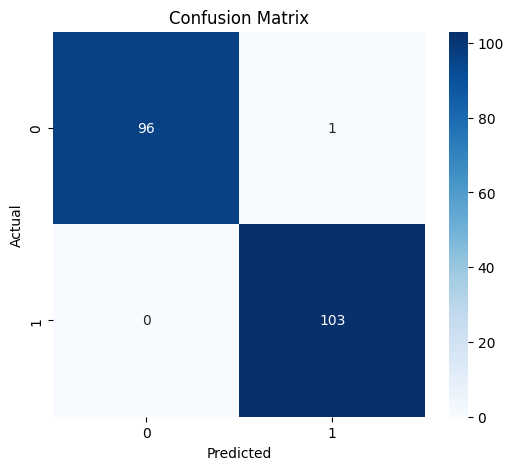

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

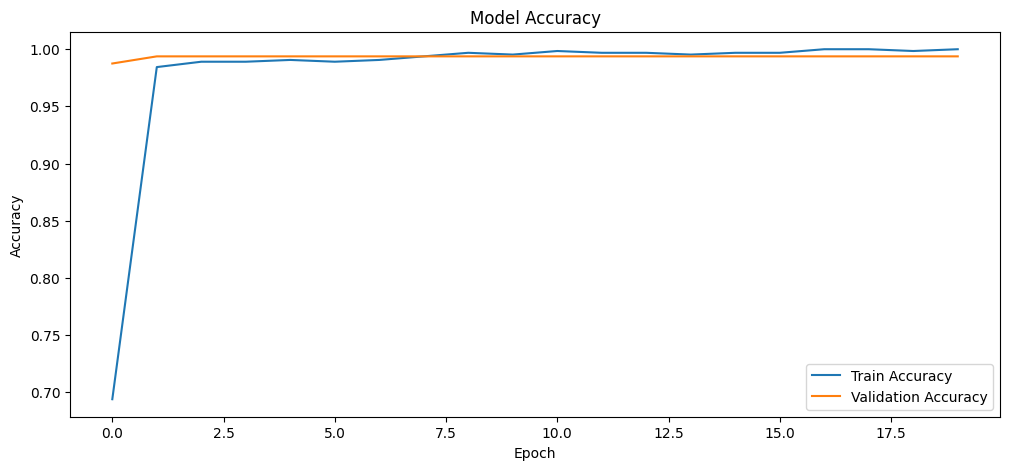

In [20]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train Accuracy",
    "Validation Accuracy"
])

plt.show()

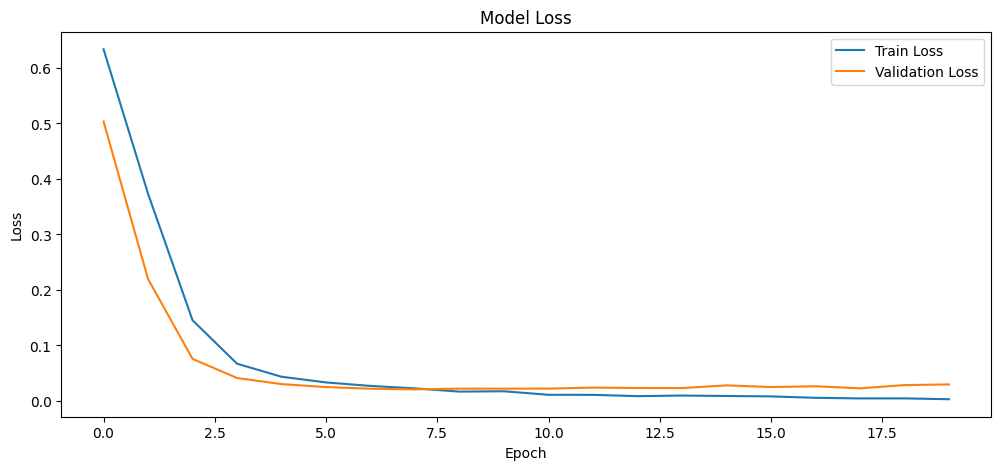

In [21]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train Loss",
    "Validation Loss"
])

plt.show()